<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Детекция объектов</b></h3>

В этом домашнем задании мы продолжим работу над детектором из семинара, поэтому при необходимости можете заимствовать оттуда любой код.

Домашнее задание можно разделить на следующие части:

* Переделываем модель [4]
  * Backbone[1],
  * Neck [2],
  * Head [1]
* Label assignment [3]:
  * TAL [3]
* Лоссы [1]:
  * CIoU loss [1]
* Кто больше? [5]
  * 0.05 mAP [1]
  * 0.1 mAP  [2]
  * 0.2 mAP [5]

**Максимальный балл:** 10 баллов. (+3 балла бонус).

In [24]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import albumentations as A
import timm

from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset
from albumentations.pytorch.transforms import ToTensorV2
from torchvision.models.detection.anchor_utils import AnchorGenerator
import io


### Загрузка данных

Мы продолжаем работу с датасетом из семинара - Halo infinite ([сслыка](https://universe.roboflow.com/graham-doerksen/halo-infinite-angel-aim)). Загрузка данных и создание датасета полностью скопированы из семинара.

Сначала загружаем данные

In [25]:
splits = {'train': 'data/train-00000-of-00001-0d6632d599c29801.parquet',
          'validation': 'data/validation-00000-of-00001-c6b77a557eeedd52.parquet',
          'test': 'data/test-00000-of-00001-866d29d8989ea915.parquet'}
df_train = pd.read_parquet("hf://datasets/Francesco/halo-infinite-angel-videogame/" + splits["train"])
df_test = pd.read_parquet("hf://datasets/Francesco/halo-infinite-angel-videogame/" + splits["test"])

Создаем датасет для предобработки данных

In [26]:
class HaloDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        df_objects = pd.json_normalize(dataframe['objects'])[["bbox", "category"]]
        df_images = pd.json_normalize(dataframe['image'])[["bytes"]]
        self.data = dataframe[["image_id"]].join(df_objects).join(df_images)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        """Загружаем данные и разметку для объекта с индексом `idx`.

        labels: List[int] Набор классов для каждого ббокса,
        boxes: List[List[int]] Набор ббоксов в формате (x_min, y_min, w, h).
        """
        row = self.data.iloc[idx]
        image = Image.open(io.BytesIO(row["bytes"]))
        image = np.array(image)

        target = {}
        target["image_id"] = row["image_id"]

        labels = [row["category"]] if isinstance(row["category"], int) else row['category']
        # Вычитаем единицу чтобы классы начинались с нуля
        labels = [label - 1 for label in labels]
        boxes = row['bbox'].tolist()

        if self.transform is not None:
            transformed = self.transform(image=image, bboxes=boxes, labels=labels)
            image, boxes, labels = transformed["image"], transformed["bboxes"], transformed["labels"]
        else:
            image = transforms.ToTensor()(image)

        target['boxes'] = torch.tensor(np.array(boxes), dtype=torch.float32)
        target['labels'] = torch.tensor(labels, dtype=torch.int64)
        return image, target

def collate_fn(batch):
    batch = tuple(zip(*batch))
    images = torch.stack(batch[0])
    return images, batch[1]

Чтобы модель не переобучалась, можно добавить больше аугментаций, весь список можно посмотреть тут [[ссылка](https://explore.albumentations.ai/)].

Какие можно использовать аугментации?
* Добавить зум `RandomResizedCrop`,
* Сделать цветовые аугментации типа `RandomBrightnessContrast` и/или `HueSaturationValue`,
* Добавить шум `GaussNoise`,
* Вырезать случайные части изображения `CoarseDropout`,
* И любые другие!

Аугментации можно комбинировать посредствам `A.OneOf`, `A.SomeOf` или `A.RandomOrder`.

Хоть аугментации ограничиваются только вашей фантазией, перед обучением советуем посмотреть на результат преобразований и убедиться, что изображение ещё поддается детекции:)

In [27]:
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

train_transform = A.Compose(
    [
           # Добавляй сюда свои аугментации при необходимости
        A.RandomOrder([
            A.GaussNoise(p=1),
            A.CoarseDropout(p=0.3),
            #A.RandomResizedCrop(size=(512,512),p=0.4)
        ],p=0.7),
        A.Resize(height=640, width=640, p=1.0),
        A.Normalize(mean=mean, std=std),
        ToTensorV2()
    ],
    # Раскомментируй, если аугментации изменяют ббоксы.
    # Не забудь указать верный формат для ббоксов.
    bbox_params=A.BboxParams(format='coco', label_fields=['labels'], min_visibility=0.3)
)

test_transform = A.Compose(
    [
        A.Resize(height=640, width=640, p=1.0),
        A.Normalize(mean=mean, std=std),
        ToTensorV2(),
    ]
)

Не забываем инициализировать наш датасет

In [28]:
train_dataset = HaloDataset(df_train, transform=train_transform)
test_dataset = HaloDataset(df_test, transform=test_transform)

In [29]:
from torch.utils.data import DataLoader
train_dataloader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=collate_fn)
test_dataloader = DataLoader(test_dataset, batch_size=2, shuffle=False, collate_fn=collate_fn)

## Переделываем модель [4 балла]

В семинаре мы реализовали самый базовый детектор, а сейчас настало время его улучшать.

### Backbone [1 балл]

Хорошей практикой считается размораживать несколько последних слоев в backbone, это позволяет немного улучить качество модели. Давайте улушчим класс Backbone из лекции, добавив ему возможность разморозки __k__ последних слоев или блоков (на ваш выбор).

In [30]:
class Backbone(nn.Module):
    def __init__(self, model_name = "efficientnet_b0", out_indices = (-1,-2,-3), unfreeze_last=3):
        # YOUR CODE HERE!
        super().__init__()
        self.backbone = timm.create_model(model_name, pretrained=True, features_only=True, out_indices=out_indices)

        for param in self.backbone.parameters():
            param.requires_grad = False
        # Получаем список всех блоков
        blocks = list(self.backbone.children())
        last_blocks = blocks[-unfreeze_last:]

        for block in last_blocks:
          for param in block.parameters():
            param.requires_grad = True

    def forward(self, x):
        # YOUR CODE HERE!
        return self.backbone(x)

### NECK [2 балла]

Следующее улучшение коснется шеи. Предлагаем реализовать знакомую из лекции архитектуру FPN.

#### Feature Pyramid Network

<center><img src="https://user-images.githubusercontent.com/57972646/69858594-b14a6c00-12d5-11ea-8c3e-3c17063110d3.png"/></center>


* [Feature Pyramid Networks for Object Detection](https://arxiv.org/abs/1612.03144)

Она состоит из top-down пути, в котором происходит 2 вещи:
1. Увеличивается пространственная размерность фичей,
2. С помощью скипконнекшеннов, добавляются фичи из backbone модели.

Для увеличения пространственной размерности используется __nearest neighbor upsampling__, а фичи из шеи и бекбоуна суммируются.

__TIPS__:
* Можете использовать базовые классы из лекции,
* Воспользуйтесь AnchorGenerator-ом, чтобы создавать якоря сразу для нескольких выходов,
* Не забудьте использовать nn.ModuleList, если захотите сделать динамическое количество голов у модели,
* Также, можно добавить доп конволюцию (3х3 с паддингом) у каждого выхода шеи.

In [31]:
import torch.nn as nn

class Neck(nn.Module):
    def __init__(self, in_channels, out_channels, use_activations=True ):
        # YOUR CODE HERE
      super().__init__()

      self.lateral_convs = nn.ModuleList([
            nn.Conv2d(in_ch, out_channels, kernel_size=1)
            for in_ch in in_channels
        ])

      self.upsample = nn.Upsample(scale_factor=2, mode='nearest')

      self.output_convs = nn.ModuleList([
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
            for _ in in_channels
        ])



    def forward(self, features):
        # YOUR CODE HERE
        laterals = [conv(f) for conv, f in zip(self.lateral_convs, features)]

        for i in range(len(laterals) - 1, 0, -1):
            laterals[i-1] = laterals[i-1] + self.upsample(laterals[i])


        return [conv(lat) for conv, lat in zip(self.output_convs, laterals)]


### Head [1 балл]

В качестве шеи можно выбрать __один из двух__ вариантов:

#### 1. Decoupled Head

Реализовать Decoupled Head из [YOLOX](https://arxiv.org/abs/2107.08430).
<center><img src="https://i.ibb.co/BVtBR2R3/Decoupled-head.jpg"/></center>

**TIP**: Возьмите за основу голову из семинара, тк она сильно похожа на Decoupled Head.

Изменять количество параметров у шей на разных уровнях не обязательно.

#### 2. Confidence score free head

Нужно взять за основу голову из семинара и полностью убрать предсказание confidence score. Чтобы модель предсказывала только 2 группы: ббоксы и классы.

Есть следующие способы удаления confidence score:
* Добавление нового класса ФОН. Обычно его обозначают нулевым классом.
* Присваивание ббоксам БЕЗ объекта вектор из нулей в качестве таргета.

Выберете тот, который вам больше нравится и будте внимательны при расчете лосса!

**Важно!** Удаление confidence score повлияет на следующие методы из семинара:
* target_assign
* ComputeLoss
* _filter_predictions

In [32]:
import torch
import torch.nn as nn

class Head(nn.Module):
    """Decoupled Head из YOLOX с двумя независимыми ветвями."""

    def __init__(self, in_channels, num_anchors, num_classes, use_activations=True):
        super().__init__()

        self.num_anchors = num_anchors
        self.num_classes = num_classes

        # Classification branch (свои слои)
        self.cls_conv1 = nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1)
        self.cls_bn1 = nn.BatchNorm2d(in_channels)
        self.cls_conv2 = nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1)
        self.cls_bn2 = nn.BatchNorm2d(in_channels)
        self.cls_pred = nn.Conv2d(in_channels, num_anchors * num_classes, kernel_size=1)

        # Regression branch (свои слои)
        self.reg_conv1 = nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1)
        self.reg_bn1 = nn.BatchNorm2d(in_channels)
        self.reg_conv2 = nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1)
        self.reg_bn2 = nn.BatchNorm2d(in_channels)
        # 4 координаты + 1 objectness = 5
        self.reg_pred = nn.Conv2d(in_channels, num_anchors * 5, kernel_size=1)

        # ✅ Единая активация для обеих ветвей
        self.act = nn.SiLU() if use_activations else nn.Identity()

    def forward(self, x):
        # Classification branch
        # ✅ Используем self.act вместо self.cls_act
        cls_feat = self.act(self.cls_bn1(self.cls_conv1(x)))
        cls_feat = self.act(self.cls_bn2(self.cls_conv2(cls_feat)))
        cls_pred = self.cls_pred(cls_feat)

        # Regression branch
        # ✅ Используем self.act вместо self.reg_act
        reg_feat = self.act(self.reg_bn1(self.reg_conv1(x)))
        reg_feat = self.act(self.reg_bn2(self.reg_conv2(reg_feat)))
        reg_pred = self.reg_pred(reg_feat)

        return cls_pred, reg_pred

Теперь можно снова реализовать класс детектора с учетом всех частей выше!

In [33]:
class Detector(nn.Module):
    # YOUR CODE HERE
    def __init__(self,
                 backbone_model_name="efficientnet_b0",
                 neck_n_channels=256,
                 num_classes=4,
                 anchor_sizes=((32,), (64,), (128,)),
                 anchor_ratios=((0.5, 1.0, 2.0),)*3,
                 input_size=(640, 640),
        ):
      super().__init__()
      self.num_classes = num_classes
      self.backbone = Backbone(backbone_model_name, out_indices=(-3,-2,-1 ))

      # Получаем количество фичемапов на выходном слое
      in_channels = self.backbone.backbone.feature_info.channels()
        # Создаем шею, с учетом параметров, полученных выше
      self.neck = Neck(in_channels, out_channels=neck_n_channels)
        # Размерность выходов головы зависит от количество якорей, поэтому сначала считаем количество якорей в каждой
        # ячейке выходной фичемапы
      num_anchors = len(anchor_sizes[0]) * len(anchor_ratios[0])  # 1 * 3 = 3
      self.heads = nn.ModuleList([
        Head(in_channels=neck_n_channels, num_anchors=num_anchors, num_classes=num_classes)
        for _ in range(len(in_channels))  # 3 головы
      ])
        # Генерируем якоря
      anchor_generator = AnchorGenerator(sizes=anchor_sizes, aspect_ratios=anchor_ratios)
        # Узнаем размер выходной фичемапы
      reductions = self.backbone.backbone.feature_info.reduction()
      grid_sizes = [[input_size[0] // r, input_size[1] // r] for r in reductions]
      strides = [[r, r] for r in reductions]

        # Расчитываем координаты якорей в каждой точке выходной фичемапы.
        ###
        # Якоря хранятся в формате (x_min, y_min, x_max, y_max)!
        ###
      anchors = anchor_generator.grid_anchors(grid_sizes, strides=strides)
      anchors = torch.cat(anchors, dim=0)
        # Заранее считаем координаты якорей в формате (x_center, y_center, w, h)
        # Это пригодится для расчета лосса
      anchor_centers = (anchors[:, :2] + anchors[:, 2:]) / 2  # ✅ 2D индексация

      anchor_sizes_calc = (anchors[:, 2:] - anchors[:, :2])  # ✅ Другое имя

      self.register_buffer("anchors", anchors)
      self.register_buffer("anchor_centers", anchor_centers)
      self.register_buffer("anchor_sizes", anchor_sizes_calc)

    def forward(self, x):
    # 1. Пропускаем картинку через backbone и neck
      features = self.backbone(x)           # Список из 3 тензоров
      neck_features = self.neck(features)   # Список из 3 тензоров по 256 каналов

      # 2. Прогоняем каждый уровень через свою голову
      cls_logits_list = []
      bbox_preds_list = []

      for head, feature in zip(self.heads, neck_features):
          cls_pred, bbox_pred = head(feature)

          # Преобразуем форму: [N, C, H, W] → [N, H, W, C] → [N, H*W*num_anchors, C/num_anchors]
          N = cls_pred.shape[0]
          cls_pred = cls_pred.permute(0, 2, 3, 1).contiguous()
          cls_pred = cls_pred.view(N, -1, self.num_classes)  # [N, H*W*num_anchors, num_classes]

          bbox_pred = bbox_pred.permute(0, 2, 3, 1).contiguous()
          bbox_pred = bbox_pred.view(N, -1, 5)  # [N, H*W*num_anchors, 5]

          cls_logits_list.append(cls_pred)
          bbox_preds_list.append(bbox_pred)

      # 3. Склеиваем предсказания со всех уровней
      cls_logits = torch.cat(cls_logits_list, dim=1)  # [N, total_anchors, num_classes]
      bbox_preds = torch.cat(bbox_preds_list, dim=1)  # [N, total_anchors, 5]

      # 4. Разделяем координаты и confidence
      bbox_offsets = bbox_preds[:, :, :4]          # [N, total_anchors, 4]
      confidence_logits = bbox_preds[:, :, 4]      # [N, total_anchors]

      if self.training:
          return bbox_offsets, confidence_logits, cls_logits

      # 5. При инференсе декодируем боксы
      bboxes = self.decode_bboxes(bbox_offsets)
      confidence = torch.sigmoid(confidence_logits)
      cls_probs = torch.softmax(cls_logits, dim=-1)
      return bboxes, confidence, cls_probs


    def decode_bboxes(self, bbox_offsets):
        """Декодируем предсказанные смещения в реальные боксы по формулам YOLOv3.

        bbox_offsets: [N, total_anchors, 4]
        Возвращает: [N, total_anchors, 4] в формате (x_min, y_min, w, h)
        """
        tx = bbox_offsets[:, :, 0]  # [N, total_anchors]
        ty = bbox_offsets[:, :, 1]
        tw = bbox_offsets[:, :, 2]
        th = bbox_offsets[:, :, 3]

        # anchor_centers: [total_anchors, 2] → добавляем batch dimension → [1, total_anchors, 2]
        anchor_centers = self.anchor_centers.unsqueeze(0)  # [1, total_anchors, 2]
        anchor_sizes = self.anchor_sizes.unsqueeze(0)      # [1, total_anchors, 2]

        # Формулы YOLOv3
        center_x = anchor_centers[:, :, 0] + torch.sigmoid(tx) * anchor_sizes[:, :, 0]
        center_y = anchor_centers[:, :, 1] + torch.sigmoid(ty) * anchor_sizes[:, :, 1]

        w = torch.exp(tw) * anchor_sizes[:, :, 0]
        h = torch.exp(th) * anchor_sizes[:, :, 1]

        x_min = center_x - w / 2
        y_min = center_y - h / 2

        return torch.stack([x_min, y_min, w, h], dim=-1)  # [N, total_anchors, 4]


## Label assignment [3 балла]
В этой секции предлагается заменить функцию `assign_target` на более современный алгоритм который называется Task alignment learning.

Он описан в статье [TOOD](https://arxiv.org/abs/2108.07755) в секции 3.2. Для удобства вот его основные шаги:

1. Посчитать значение метрики для каждого предсказанного ббокса:
    
$$t = s^\alpha * u^\beta$$
    
где,
* $s$ — classification score, или вероятность принадлежности предсказанного ббокса к классу реального ббокса (**GT**);
* $u$ — IoU между предсказанным и реальным ббоксами;
* $\alpha,\ \beta$ — нормализационные константы, обычно $\alpha = 6.0, \ \beta = 1.0$.
    
2. Отфильтровать предсказания на основе **GT**.

    Для якорных детекторов, обычно, выбираются только те предсказания, центры якорей которых находятся внутри GT.
4. Для каждого **GT** выбрать несколько (обычно 5 или 13) самых подходящих предсказаний.
5. Если предсказание рассматривается в качестве подходящего для нескольких **GT** — выбрать **GT** с наибольшим пересечением по IoU.


**BAЖНО**: если будете использовать Runner из лекции, не забудьте поменять параметры  в `self.assign_target_method` в методе `_run_train_epoch`.

In [34]:
import torch
import torch.nn.functional as F


def TAL_assigner(
    bbox_offsets,          # [N, total_anchors, 4] - предсказанные смещения
    confidence_logits,     # [N, total_anchors] - objectness logits
    cls_logits,            # [N, total_anchors, num_classes] - class logits
    anchors,               # [total_anchors, 4] - якоря (x_min, y_min, x_max, y_max)
    anchor_centers,        # [total_anchors, 2] - центры якорей
    anchor_sizes,          # [total_anchors, 2] - размеры якорей
    gt_bboxes,             # Список из N тензоров [num_gt_i, 4] - GT боксы (x_min, y_min, w, h)
    gt_labels,             # Список из N тензоров [num_gt_i] - GT метки
    topk=13,               # Количество позитивных якорей на GT
    alpha=0.5,             # Вес для classification score
    beta=6.0,              # Вес для IoU
    eps=1e-9               # Для численной стабильности
):
    """
    Task-Aligned Assigner из TOAD.

    Returns:
        assigned_labels: [N, total_anchors] - метки для каждого якоря (-1 = негативный)
        assigned_bboxes: [N, total_anchors, 4] - целевые боксы в формате (x_min, y_min, w, h)
        assigned_ious: [N, total_anchors] - IoU для каждого якоря
    """
    device = bbox_offsets.device
    N = bbox_offsets.shape[0]
    total_anchors = bbox_offsets.shape[1]
    num_classes = cls_logits.shape[2]

    # 1. Декодируем предсказанные боксы из смещений
    pred_bboxes = decode_bboxes_for_assigner(
        bbox_offsets, anchor_centers, anchor_sizes
    )  # [N, total_anchors, 4] в формате (x_min, y_min, w, h)

    # Конвертируем в формат (x_min, y_min, x_max, y_max) для IoU
    pred_bboxes_xyxy = ltrb_to_xyxy(pred_bboxes)

    # 2. Считаем classification scores
    cls_scores = F.softmax(cls_logits, dim=-1)  # [N, total_anchors, num_classes]
    confidence = torch.sigmoid(confidence_logits)  # [N, total_anchors]

    # Итоговый score = confidence × max_class_score
    # (или можно использовать просто max_class_score)

    # 3. Инициализируем результаты
    assigned_labels = torch.full((N, total_anchors), -1, dtype=torch.long, device=device)
    assigned_bboxes = torch.zeros((N, total_anchors, 4), dtype=torch.float32, device=device)
    assigned_ious = torch.zeros((N, total_anchors), dtype=torch.float32, device=device)

    # 4. Обрабатываем каждую картинку в батче отдельно
    for i in range(N):
        gt_bbox = gt_bboxes[i]  # [num_gt, 4]
        gt_label = gt_labels[i]  # [num_gt]

        if len(gt_bbox) == 0:
            continue

        # Конвертируем GT в xyxy формат
        gt_bbox_xyxy = ltrb_to_xyxy(gt_bbox)  # [num_gt, 4]

        # 5. Находим якоря, центры которых попадают внутрь GT боксов
        # anchor_centers: [total_anchors, 2]
        # gt_bbox_xyxy: [num_gt, 4]

        # Проверяем: center_x ∈ [x_min, x_max] и center_y ∈ [y_min, y_max]
        is_in_gts = (
            (anchor_centers[:, 0:1] >= gt_bbox_xyxy[:, 0:1].T) &  # x >= x_min
            (anchor_centers[:, 0:1] <= gt_bbox_xyxy[:, 2:3].T) &  # x <= x_max
            (anchor_centers[:, 1:2] >= gt_bbox_xyxy[:, 1:2].T) &  # y >= y_min
            (anchor_centers[:, 1:2] <= gt_bbox_xyxy[:, 3:4].T)    # y <= y_max
        )  # [total_anchors, num_gt]

        # 6. Считаем IoU между предсказанными боксами и GT
        # pred_bboxes_xyxy[i]: [total_anchors, 4]
        # gt_bbox_xyxy: [num_gt, 4]
        ious = calculate_iou(
            pred_bboxes_xyxy[i].unsqueeze(1),  # [total_anchors, 1, 4]
            gt_bbox_xyxy.unsqueeze(0)           # [1, num_gt, 4]
        )  # [total_anchors, num_gt]

        # 7. Считаем classification score для каждого GT класса
        # cls_scores[i]: [total_anchors, num_classes]
        # gt_label: [num_gt]
        cls_scores_for_gt = cls_scores[i][:, gt_label]  # [total_anchors, num_gt]

        # 8. Считаем метрику t = s^α × u^β
        alignment_metrics = (cls_scores_for_gt ** alpha) * (ious ** beta)  # [total_anchors, num_gt]

        # Обнуляем якоря, которые не попадают в GT
        alignment_metrics = alignment_metrics * is_in_gts.float()

        # 9. Для каждого GT выбираем top-k якорей с максимальным t
        topk_metrics, topk_indices = torch.topk(
            alignment_metrics,
            min(topk, alignment_metrics.shape[0]),
            dim=0
        )  # [topk, num_gt]

        # 10. Назначаем позитивные якоря
        for j in range(gt_bbox.shape[0]):
            # Индексы top-k якорей для этого GT
            positive_indices = topk_indices[:, j]

            # Проверяем, что метрика > 0 (якорь действительно внутри GT)
            valid_mask = topk_metrics[:, j] > 0
            positive_indices = positive_indices[valid_mask]

            if len(positive_indices) == 0:
                continue

            # Назначаем метки
            assigned_labels[i, positive_indices] = gt_label[j]

            # Назначаем целевые боксы
            assigned_bboxes[i, positive_indices] = gt_bbox[j]

            # Назначаем IoU
            assigned_ious[i, positive_indices] = ious[positive_indices, j]

    return assigned_labels, assigned_bboxes, assigned_ious


def decode_bboxes_for_assigner(bbox_offsets, anchor_centers, anchor_sizes):
    """Декодирует смещения в боксы (без batch dimension для anchor_centers/sizes)."""
    tx = bbox_offsets[:, :, 0]
    ty = bbox_offsets[:, :, 1]
    tw = bbox_offsets[:, :, 2]
    th = bbox_offsets[:, :, 3]

    anchor_centers = anchor_centers.unsqueeze(0)  # [1, total_anchors, 2]
    anchor_sizes = anchor_sizes.unsqueeze(0)

    center_x = anchor_centers[:, :, 0] + torch.sigmoid(tx) * anchor_sizes[:, :, 0]
    center_y = anchor_centers[:, :, 1] + torch.sigmoid(ty) * anchor_sizes[:, :, 1]

    w = torch.exp(tw) * anchor_sizes[:, :, 0]
    h = torch.exp(th) * anchor_sizes[:, :, 1]

    x_min = center_x - w / 2
    y_min = center_y - h / 2
    x_max = center_x + w / 2
    y_max = center_y + h / 2

    return torch.stack([x_min, y_min, x_max, y_max], dim=-1)


def ltrb_to_xyxy(bboxes):
    """Конвертирует (x_min, y_min, w, h) в (x_min, y_min, x_max, y_max)."""
    x_min = bboxes[..., 0]
    y_min = bboxes[..., 1]
    w = bboxes[..., 2]
    h = bboxes[..., 3]

    x_max = x_min + w
    y_max = y_min + h

    return torch.stack([x_min, y_min, x_max, y_max], dim=-1)


def calculate_iou(boxes1, boxes2):
    """
    Считает IoU между двумя наборами боксов.

    boxes1: [..., 4] в формате (x_min, y_min, x_max, y_max)
    boxes2: [..., 4] в формате (x_min, y_min, x_max, y_max)

    Returns: IoU матрица [...]
    """
    # Находим координаты пересечения
    x_min = torch.max(boxes1[..., 0], boxes2[..., 0])
    y_min = torch.max(boxes1[..., 1], boxes2[..., 1])
    x_max = torch.min(boxes1[..., 2], boxes2[..., 2])
    y_max = torch.min(boxes1[..., 3], boxes2[..., 3])

    # Площадь пересечения
    intersection = torch.clamp(x_max - x_min, min=0) * torch.clamp(y_max - y_min, min=0)

    # Площади боксов
    area1 = (boxes1[..., 2] - boxes1[..., 0]) * (boxes1[..., 3] - boxes1[..., 1])
    area2 = (boxes2[..., 2] - boxes2[..., 0]) * (boxes2[..., 3] - boxes2[..., 1])

    # IoU
    union = area1 + area2 - intersection
    iou = intersection / (union + 1e-9)

    return iou

### DIoU [1]

Вместо SmoothL1, который используется в семинаре, реализуем лосс, основанный на пересечении ббоксов. В качестве тренировки давайте напишем Distance Intersection over Union (DIoU).

<center><img src=https://wikidocs.net/images/page/163613/Free_Fig_5.png></center>

Для его реализации разобъем задачу на части:

**1. Реализуем IoU:**

Пусть даны координаты для предсказанного ($B^p$) и истинного ($B^g$) ббоксов в формате XYXY или VOC PASCAL (левый верхний и правый нижний углы):

$B^p=(x^p_1, y^p_1, x^p_2, y^p_2)$, $B^g=(x^g_1, y^g_1, x^g_2, y^g_2)$, тогда алгоритм расчета будет следующий:

    1. Найдем площади обоих ббоксов:
$$ A^p = (x^p_2 - x^p_1) * (y^p_2 - y^p_1) $$
$$ A^g = (x^g_2 - x^g_1) * (y^g_2 - y^g_1) $$

    2. Посчитаем пересечение между ббоксами:

Тут мы предлагаем вам подумать как в общем виде можно расчитать размеры ббокса, который будет являться пересечением $B^p$ и $B^g$, а затем посчитать его площадь:

$$x^I_1 = \qquad \qquad y^I_1 = $$
$$x^I_2 = \qquad \qquad y^I_2 = $$

В общем виде, площать будет записываться следующим образом:

Если $x^I_2 > x^I_1$ & $y^I_2 > y^I_1$, тогда:

$$I = (x^I_2 - x^I_1) * (y^I_2 - y^I_1)$$

Иначе, $I = 0$.

    3. Считаем объединение ббоксов.

Мы можем посчитать эту площадь как сумму площадей двух ббоксов минус площадь пересечения (тк мы считаем её два раз в сумме площадей):

$$U = A^p + A^g - I$$

    4. Вычисляем IoU.

$$IoU = \frac{I}{U}$$

**2. Посчитаем диагональ выпуклой оболочки:**

Для расчета диагонали, сначала выпишите координаты верхнего левого и правого нижнего углов. Подумайте, чему будут равны эти координаты в общем случае?

$$x^c_1 = \qquad \qquad y^c_1 = $$
$$x^c_2 = \qquad \qquad y^c_2 = $$

Подсказка: Нарисуйте несколько вариантов пересечений предсказания и GT на бумажке, и выпишите координаты для выпуклой оболочки.

Тогда квадрат диагонали можно посчитать по формуле:

$$c^2 = (x^c_2 - x^c_1)^2 + (y^c_2 - y^c_1)^2$$

**3. Рассчитаем расстояние между цетрами ббоксов:**

Сначала находим координаты центров каждого из ббоксов (если ббоксы в формате YOLO, то и считать ничего не нужно), затем считаем Евклидово расстояние между центрами.

$d = $

Собираем все части вместе и считаем лосс по формуле:

$$ DIoU = 1 - IoU + \frac{d^2}{c^2}$$

Помните, что пар ббоксов может быть много! Возвращайте усредненное значение лосса.

In [35]:
from torchvision.ops import distance_box_iou_loss
import torch

In [36]:
def gen_bbox(num_boxes=10):
    min_corner = torch.randint(0, 100, (num_boxes, 2))
    max_corner = torch.randint(50, 150, (num_boxes, 2))

    for i in range(2):
        wrong_order = min_corner[:, i] > max_corner[:, i]
        if wrong_order.any():
            min_corner[wrong_order, i], max_corner[wrong_order, i] = max_corner[wrong_order, i], min_corner[wrong_order, i]
    return torch.cat((min_corner, max_corner), dim=1)

In [37]:
pred_boxes = gen_bbox(num_boxes=100)
true_boxes = gen_bbox(num_boxes=100)

In [38]:
print(f" DIoU: {distance_box_iou_loss(pred_boxes, true_boxes, reduction="mean").item()}")

 DIoU: 1.016169786453247


In [39]:
print(pred_boxes.shape)

torch.Size([100, 4])


In [40]:
def diou_loss(pred_boxes, gt_boxes):
  # TODO
    pred_x1 = pred_boxes[:, 0]
    pred_y1 = pred_boxes[:, 1]
    pred_x2 = pred_boxes[:, 2]
    pred_y2 = pred_boxes[:, 3]

    # 2. Координаты GT боксов
    gt_x1 = gt_boxes[:, 0]
    gt_y1 = gt_boxes[:, 1]
    gt_x2 = gt_boxes[:, 2]
    gt_y2 = gt_boxes[:, 3]

    # 3. Площадь пересечения (intersection)
    inter_x1 = torch.max(pred_x1, gt_x1)
    inter_y1 = torch.max(pred_y1, gt_y1)
    inter_x2 = torch.min(pred_x2, gt_x2)
    inter_y2 = torch.min(pred_y2, gt_y2)

    inter_w = torch.clamp(inter_x2 - inter_x1, min=0)
    inter_h = torch.clamp(inter_y2 - inter_y1, min=0)
    intersection = inter_w * inter_h

    # 4. Площади боксов
    pred_area = (pred_x2 - pred_x1) * (pred_y2 - pred_y1)
    gt_area = (gt_x2 - gt_x1) * (gt_y2 - gt_y1)

    # 5. IoU
    union = pred_area + gt_area - intersection
    iou = intersection / (union + 1e-9)  # +eps для стабильности

    # 6. Центры боксов
    pred_center_x = (pred_x1 + pred_x2) / 2
    pred_center_y = (pred_y1 + pred_y2) / 2
    gt_center_x = (gt_x1 + gt_x2) / 2
    gt_center_y = (gt_y1 + gt_y2) / 2

    # 7. Расстояние между центрами (d²)
    d_squared = (pred_center_x - gt_center_x) ** 2 + (pred_center_y - gt_center_y) ** 2

    # 8. Наименьший охватывающий бокс (enclosing box)
    enclose_x1 = torch.min(pred_x1, gt_x1)
    enclose_y1 = torch.min(pred_y1, gt_y1)
    enclose_x2 = torch.max(pred_x2, gt_x2)
    enclose_y2 = torch.max(pred_y2, gt_y2)

    # 9. Диагональ охватывающего бокса (c²)
    c_squared = (enclose_x2 - enclose_x1) ** 2 + (enclose_y2 - enclose_y1) ** 2

    # 10. D-IoU
    diou = iou - (d_squared / (c_squared + 1e-9))

    # 11. Loss = 1 - D-IoU
    loss = 1 - diou

    return loss.mean()  # Усредняем по батчу

In [41]:
import numpy as np
pred_boxes = gen_bbox(num_boxes=1000)
true_boxes = gen_bbox(num_boxes=1000)

# проверим что написанный лосс выдает те же результаты что и лосс из торча.
assert np.isclose(diou_loss(pred_boxes, true_boxes), distance_box_iou_loss(pred_boxes, true_boxes, reduction="mean"))

## Кто больше? [5 баллов]

Наконец то мы дошли до самый интересной части. Тут мы раздаем очки за mAP'ы!

Все что вы написали выше вам поможет улучшить качество итогового детектора, настало время узнать насколько сильно :)

За достижения порога по mAP на тестовом наборе вы получаете баллы:
* 0.05 mAP [1]
* 0.1 mAP [2]
* 0.2 mAP [5]


**TIPS**:
1. На семинаре мы специально не унифицировали формат ббоксов между методами, чтобы обратить ваше внимание что за этим нужно следить. Чтобы было проще, сразу унифицируете формат по всему ноутбуку. Советуем использовать формат xyxy, тк IoU и NMS из torch используют именно этот формат. (Не забудьте поменять формат у таргета в `HaloDataset`).

2. Попробуйте перейти к IoU-based лоссу при обучении. То есть обучать не смещения, а сразу предсказывать ббокс.

3. Поэксперементируйте с подходами target assignment'а в процессе обучения. Например, можно на первых итерациях использовать обычный метод, а затем подключить TAL.

4. Добавьте аугментаций!

Можно взять [albumentations](https://albumentations.ai/docs/getting_started/bounding_boxes_augmentation/), библиотеку, которую мы использовали всеминаре. Или базовые аугментации из торча [тык](https://pytorch.org/vision/main/transforms.html). Если будете использовать торч, не забудте про ббоксы, transforms из коробки не будет их агументировать.

5. Можете реализовать другую шею, которую мы обсуждали на лекции [Path Aggregation Network](https://arxiv.org/abs/1803.01534) она точно улучшит ваше итоговое качество.

6. Попробуйте добавлять различные блоки из YOLO архитектур в шею вместо единичных конволюционных слоев. (Например, замените конволюции 3х3 на CSP блоки).

7. Попробуйте заменить NMS на другой метод (WeightedNMS, SoftNMS, etc.). Немного ссылок:
    * Статья про SoftNMS [тык](https://arxiv.org/pdf/1704.04503)
    * Статья про WeightedNMS [тык](https://openaccess.thecvf.com/content_ICCV_2017_workshops/papers/w14/Zhou_CAD_Scale_Invariant_ICCV_2017_paper.pdf)
    * Есть их реализация, правда на нумбе [git](https://github.com/ZFTurbo/Weighted-Boxes-Fusion?tab=readme-ov-file)

8. Не бойтесь эксперементировать и удачи!

Также, напишите развернутые ответы на следующие вопросы:

**Questions:**
1. Какой метод label assignment'a помогает лучше обучаться модели? Почему?
2. Какое из сделаных вами улучшений внесло наибольший вклад в качество модели? Как вы думаете, почему это произошло?
3. Какое из сделанных вами улучшений вообще не изменило метрику? Как вы думаете, почему это произошло?

In [42]:
import torch
import torch.nn.functional as F


def train_epoch(model, dataloader, optimizer, device):
    """
    Один проход по тренировочному датасету.

    Args:
        model: ваша модель Detector
        dataloader: DataLoader с тренировочными данными
        optimizer: оптимизатор (Adam, SGD)
        device: 'cuda' или 'cpu'

    Returns:
        avg_loss: средний loss за эпоху
    """
    model.train()  # Включаем режим обучения
    total_loss = 0.0

    for batch_idx, (images, targets) in enumerate(dataloader):
        # Переносим данные на GPU/CPU
        images = images.to(device)
        targets = [{k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in t.items()} for t in targets]

        # Forward pass
        bbox_offsets, confidence_logits, cls_logits = model(images)

        # TAL assigner: назначаем якорям метки и целевые боксы
        assigned_labels, assigned_bboxes, assigned_ious = TAL_assigner(
            bbox_offsets=bbox_offsets,
            confidence_logits=confidence_logits,
            cls_logits=cls_logits,
            anchors=model.anchors,
            anchor_centers=model.anchor_centers,
            anchor_sizes=model.anchor_sizes,
            gt_bboxes=[t['boxes'] for t in targets],
            gt_labels=[t['labels'] for t in targets],
            topk=13,
            alpha=0.5,
            beta=6.0
        )

        # Считаем потери

        # 1. Classification loss (CrossEntropy для позитивных якорей)
        # assigned_labels: [N, total_anchors], -1 для негативных
        positive_mask = assigned_labels >= 0  # [N, total_anchors]

        if positive_mask.sum() > 0:
            # Берем только позитивные якоря
            cls_logits_pos = cls_logits[positive_mask]  # [num_pos, num_classes]
            labels_pos = assigned_labels[positive_mask]  # [num_pos]

            cls_loss = F.cross_entropy(cls_logits_pos, labels_pos)
        else:
            cls_loss = torch.tensor(0.0, device=device)

        # 2. Regression loss (D-IoU для позитивных якорей)
        if positive_mask.sum() > 0:
            pred_bboxes_pos = model.decode_bboxes(bbox_offsets)[positive_mask]  # [num_pos, 4]
            gt_bboxes_pos = assigned_bboxes[positive_mask]  # [num_pos, 4]

            reg_loss = diou_loss(pred_bboxes_pos, gt_bboxes_pos)
        else:
            reg_loss = torch.tensor(0.0, device=device)

        # 3. Confidence loss (BCE для всех якорей)
        # Позитивные: target = 1, Негативные: target = 0
        confidence_targets = positive_mask.float()  # [N, total_anchors]
        conf_loss = F.binary_cross_entropy_with_logits(
            confidence_logits,
            confidence_targets
        )

        # Общий loss
        loss = cls_loss + reg_loss + conf_loss

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Печатаем прогресс каждые 10 батчей
        if (batch_idx + 1) % 10 == 0:
            print(f"Batch {batch_idx + 1}/{len(dataloader)}, Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(dataloader)
    return avg_loss
# Место для обучения, валидации и экспериментов!


In [43]:
@torch.no_grad()  # Отключаем вычисление градиентов
def validate(model, dataloader, device):
    """
    Оценка модели на валидационном датасете.

    Args:
        model: ваша модель Detector
        dataloader: DataLoader с валидационными данными
        device: 'cuda' или 'cpu'

    Returns:
        avg_loss: средний loss
        metrics: словарь с метриками (precision, recall, mAP)
    """
    model.eval()  # Включаем режим оценки
    total_loss = 0.0

    all_predictions = []  # Для расчета mAP
    all_targets = []

    for images, targets in dataloader:
        images = images.to(device)
        targets = [{k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in t.items()} for t in targets]

        # Forward pass
        bbox_offsets, confidence_logits, cls_logits = model(images)

        # TAL assigner
        assigned_labels, assigned_bboxes, assigned_ious = TAL_assigner(
            bbox_offsets=bbox_offsets,
            confidence_logits=confidence_logits,
            cls_logits=cls_logits,
            anchors=model.anchors,
            anchor_centers=model.anchor_centers,
            anchor_sizes=model.anchor_sizes,
            gt_bboxes=[t['boxes'] for t in targets],
            gt_labels=[t['labels'] for t in targets],
            topk=13,
            alpha=0.5,
            beta=6.0
        )

        # Считаем потери (как в train_epoch)
        positive_mask = assigned_labels >= 0

        if positive_mask.sum() > 0:
            cls_logits_pos = cls_logits[positive_mask]
            labels_pos = assigned_labels[positive_mask]
            cls_loss = F.cross_entropy(cls_logits_pos, labels_pos)

            pred_bboxes_pos = model.decode_bboxes(bbox_offsets)[positive_mask]
            gt_bboxes_pos = assigned_bboxes[positive_mask]
            reg_loss = diou_loss(pred_bboxes_pos, gt_bboxes_pos)
        else:
            cls_loss = torch.tensor(0.0, device=device)
            reg_loss = torch.tensor(0.0, device=device)

        confidence_targets = positive_mask.float()
        conf_loss = F.binary_cross_entropy_with_logits(
            confidence_logits,
            confidence_targets
        )

        loss = cls_loss + reg_loss + conf_loss
        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)

    print(f"Validation Loss: {avg_loss:.4f}")

    return avg_loss

In [44]:
def train_model(model, train_dataloader, val_dataloader, optimizer,
                num_epochs=50, device='cuda'):
    """
    Полный цикл обучения модели.

    Args:
        model: ваша модель Detector
        train_dataloader: DataLoader для обучения
        val_dataloader: DataLoader для валидации
        optimizer: оптимизатор
        num_epochs: количество эпох
        device: 'cuda' или 'cpu'

    Returns:
        model: обученная модель
        history: список losses по эпохам
    """
    model.to(device)
    history = {'train_loss': [], 'val_loss': []}

    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        print(f"\n{'='*50}")
        print(f"Epoch {epoch + 1}/{num_epochs}")
        print(f"{'='*50}")

        # Обучение
        train_loss = train_epoch(model, train_dataloader, optimizer, device)
        print(f"Train Loss: {train_loss:.4f}")

        # Валидация
        val_loss = validate(model, val_dataloader, device)

        # Сохраняем историю
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        # Сохраняем лучшую модель
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_model.pth')
            print(f"✓ Saved best model with val_loss: {best_val_loss:.4f}")

        # Learning rate scheduler (опционально)
        # scheduler.step()

    print("\nTraining completed!")
    return model, history

In [45]:
def train_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0.0

    # Прогресс-бар для батчей
    pbar = tqdm(dataloader, desc="🔄 Training", leave=False)

    for images, targets in pbar:
        images = images.to(device)
        targets = [{k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in t.items()} for t in targets]

        # Forward pass
        bbox_offsets, confidence_logits, cls_logits = model(images)

        # TAL assigner
        assigned_labels, assigned_bboxes, assigned_ious = TAL_assigner(
            bbox_offsets=bbox_offsets, confidence_logits=confidence_logits, cls_logits=cls_logits,
            anchors=model.anchors, anchor_centers=model.anchor_centers, anchor_sizes=model.anchor_sizes,
            gt_bboxes=[t['boxes'] for t in targets], gt_labels=[t['labels'] for t in targets],
            topk=13, alpha=0.5, beta=6.0
        )

        # Loss calculation
        positive_mask = assigned_labels >= 0
        cls_loss = F.cross_entropy(cls_logits[positive_mask], assigned_labels[positive_mask]) if positive_mask.sum() > 0 else torch.tensor(0.0, device=device)
        reg_loss = diou_loss(model.decode_bboxes(bbox_offsets)[positive_mask], assigned_bboxes[positive_mask]) if positive_mask.sum() > 0 else torch.tensor(0.0, device=device)
        conf_loss = F.binary_cross_entropy_with_logits(confidence_logits, positive_mask.float())

        loss = cls_loss + reg_loss + conf_loss

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        # Обновляем инфо в прогресс-баре
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    return total_loss / len(dataloader)


@torch.no_grad()
def validate(model, dataloader, device):
    model.eval()
    total_loss = 0.0

    pbar = tqdm(dataloader, desc="📉 Validating", leave=False)

    for images, targets in pbar:
        images = images.to(device)
        targets = [{k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in t.items()} for t in targets]

        bbox_offsets, confidence_logits, cls_logits = model(images)

        assigned_labels, assigned_bboxes, assigned_ious = TAL_assigner(
            bbox_offsets=bbox_offsets, confidence_logits=confidence_logits, cls_logits=cls_logits,
            anchors=model.anchors, anchor_centers=model.anchor_centers, anchor_sizes=model.anchor_sizes,
            gt_bboxes=[t['boxes'] for t in targets], gt_labels=[t['labels'] for t in targets],
            topk=13, alpha=0.5, beta=6.0
        )

        positive_mask = assigned_labels >= 0
        cls_loss = F.cross_entropy(cls_logits[positive_mask], assigned_labels[positive_mask]) if positive_mask.sum() > 0 else torch.tensor(0.0, device=device)
        reg_loss = diou_loss(model.decode_bboxes(bbox_offsets)[positive_mask], assigned_bboxes[positive_mask]) if positive_mask.sum() > 0 else torch.tensor(0.0, device=device)
        conf_loss = F.binary_cross_entropy_with_logits(confidence_logits, positive_mask.float())

        loss = cls_loss + reg_loss + conf_loss
        total_loss += loss.item()
        pbar.set_postfix({"val_loss": f"{loss.item():.4f}"})

    return total_loss / len(dataloader)


def train_model(model, train_dataloader, val_dataloader, optimizer,
                num_epochs=50, device='cuda'):
    model.to(device)
    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        print(f"\n{''*20} Epoch {epoch + 1}/{num_epochs} {'🟢'*20}")

        train_loss = train_epoch(model, train_dataloader, optimizer, device)
        val_loss = validate(model, val_dataloader, device)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        # Красивый вывод результатов эпохи
        print(f"📊 Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_model.pth')
            print(f"🏆 Новый рекорд! Модель сохранена. Val Loss: {best_val_loss:.4f}")
        else:
            print(f"📉 Val Loss не улучшился. Лучший: {best_val_loss:.4f}")

    print(f"\n🎉 Обучение завершено! Лучший Val Loss: {best_val_loss:.4f}")
    return model, history

In [47]:
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

In [48]:
# 1. Создаем модель
model = Detector(
    backbone_model_name="efficientnet_b0",
    neck_n_channels=256,
    num_classes=4,
    anchor_sizes=((32,), (64,), (128,)),
    anchor_ratios=((0.5, 1.0, 2.0),)*3,
    input_size=(640, 640)
)

# 2. Оптимизатор
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# 3. DataLoader'ы (предполагается, что они уже созданы)
# train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)
# val_dataloader = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)

# 4. Запускаем обучение
model, history = train_model(
    model=model,
    train_dataloader=train_dataloader,
    val_dataloader=test_dataloader,
    optimizer=optimizer,
    num_epochs=10,
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

# 5. Загружаем лучшую модель
model.load_state_dict(torch.load('best_model.pth'))


 Epoch 1/10 🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢


🔄 Training:   0%|          | 0/231 [00:00<?, ?it/s]

📉 Validating:   0%|          | 0/68 [00:00<?, ?it/s]

📊 Train Loss: 2.6307 | Val Loss: 0.8292
🏆 Новый рекорд! Модель сохранена. Val Loss: 0.8292

 Epoch 2/10 🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢


🔄 Training:   0%|          | 0/231 [00:00<?, ?it/s]

...

📊 Train Loss: 1.9027 | Val Loss: 0.7170
📉 Val Loss не улучшился. Лучший: 0.7118

 Epoch 10/10 🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢


🔄 Training:   0%|          | 0/231 [00:00<?, ?it/s]

📉 Validating:   0%|          | 0/68 [00:00<?, ?it/s]

📊 Train Loss: 1.9184 | Val Loss: 0.7180
📉 Val Loss не улучшился. Лучший: 0.7118

🎉 Обучение завершено! Лучший Val Loss: 0.7118


<All keys matched successfully>

In [50]:
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

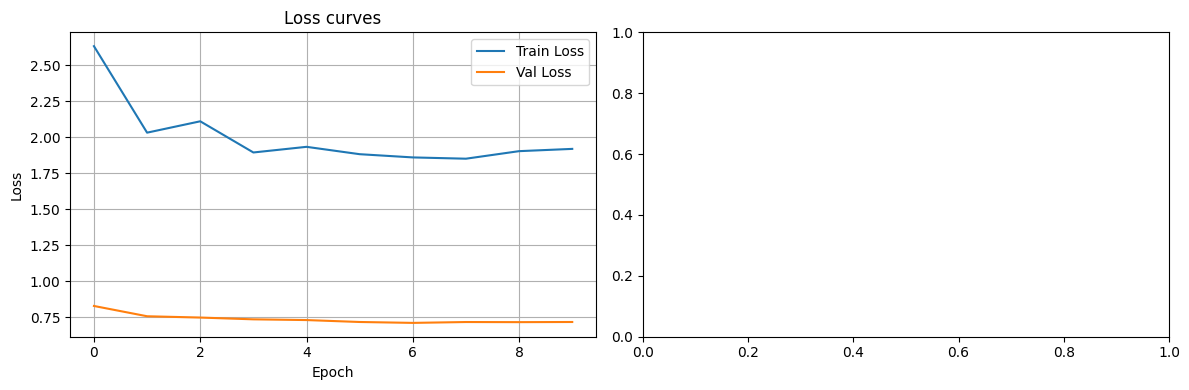

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss curves')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
valid_mAP = [m for m in history.get('mAP', []) if m is not None]
if valid_mAP:
    plt.plot(range(0, len(valid_mAP)*5, 5), valid_mAP, marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('mAP')
    plt.title('mAP over epochs')
    plt.grid(True)

plt.tight_layout()
plt.show()

Ниже определена вспомогательная функция для валидации качества. Можете использовать `Runner.validate`. Важное уточнение, ей нужен метод для фильтрации предсказаний. Можете тоже скопировать его из семинара, если он у вас не менялся.

In [51]:
class Runner:
    """ Базовый класс для обучения и валидации модели.

    Параметры
    ---------
    model : torch модель, которая будет обучаться.
    compute_loss : экземпляр класса ComputeLoss (или другого с реализованным методом __call__).
    optimizer : torch optimizer
    train_dataloader : torch dataloader семплирующий данные для обучения модели.
    assign_target_method : callable, который решает задачу сопоставления якорей и таргета (например, assign_target)
    deivce : девайс на котором будет происходить обучения, по дефолту "cpu"
    scheduler : torch scheduler
    assign_target_kwargs : доп параметры для функции в `assign_target_method`,
    val_dataloader : torch dataloader загружающий валидационные данные.
    score_threshold : При расчете метрики на валидации, все предсказания,
        с (confidence score * cls_probs) < score_threshold будут проигнорированны.
    nms_threshold : Предсказания, имеющие пересечение по IoU >= nms_threshold будут считаться одним предсказанием.
    max_boxes_per_cls : Максимальное количество ббоксов на изображение для одного класса после фильтрации по `score_threshold`.
    """
    def __init__(self, model, compute_loss, optimizer, train_dataloader, assign_target_method, device=None,
                 scheduler=None, assign_target_kwargs=None,
                 val_dataloader=None, val_every=5, score_threshold=0.1, nms_threshold=0.5, max_boxes_per_cls=8):
        self.model = model
        self.compute_loss = compute_loss
        self.optimizer = optimizer
        self.train_dataloader = train_dataloader
        assign_target_kwargs = {} if assign_target_kwargs is None else assign_target_kwargs
        self.assign_target_method = partial(assign_target_method, **assign_target_kwargs)
        self.device = "cpu" if device is None else device
        self.scheduler = scheduler

        # Валидационные параметры
        self.val_dataloader = val_dataloader
        self.val_every = val_every
        self.score_threshold = score_threshold
        self.nms_threshold = nms_threshold
        self.max_boxes_per_cls = max_boxes_per_cls

        # Вспомогательные массивы
        self.batch_loss = []
        self.epoch_loss = []
        self.val_metric = []

    def _run_train_epoch(self, dataloader, verbose=True):
        """ Обучить модель одну эпоху на данных из `dataloader` """
        self.model.train()
        batch_loss = []
        for images, targets in (pbar := tqdm(dataloader, desc=f"Process train epoch", leave=False)):
            images = images.to(self.device)
            outputs = self.model(images)

            anchors = self.model.anchors.view(-1, 4)
            accum_loss = 0.0
            for ix in range(images.shape[0]):
                gt_boxes = targets[ix]['boxes'].to(self.device)
                gt_labels = targets[ix]['labels'].to(self.device)
                # выбираем какие якоря будут использоваться при расчете лосса.
                assigned_targets = self.assign_target_method(anchors, gt_boxes, gt_labels,
                                                             num_classes=model.num_classes)
                # Считаем лосс на основании предсказаний модели и таргетов.
                outputs_ixs = [out[ix] for out in outputs]
                loss = self.compute_loss(outputs_ixs, assigned_targets)
                accum_loss += loss
            accum_loss = accum_loss / images.shape[0]
            batch_loss.append(accum_loss.cpu().detach().item())

            # Делаем шаг оптимизатора после расчета лосса для всех элементов батча
            self.optimizer.zero_grad()
            accum_loss.backward()
            self.optimizer.step()
        # Обновляем описание tqdm бара усредненным значением лосса за предыдущй батч
            if verbose:
                pbar.set_description(f"Current batch loss: {batch_loss[-1]:.4}")
        return batch_loss

    def train(self, num_epochs=10, verbose=True):
        """ Обучаем модель заданное количество эпох. """
        val_desc = ""
        for epoch in (epoch_pbar := tqdm(range(1, num_epochs+1), desc="Train epoch", total=num_epochs)):
            # Обучаем модель одну эпоху
            loss = self._run_train_epoch(self.train_dataloader, verbose=verbose)
            self.batch_loss.extend(loss)
            self.epoch_loss.append(np.mean(self.batch_loss[-len(self.train_dataloader):]))

            # Делаем валидацию, если был передан валидационный датасет
            if self.val_dataloader is not None and epoch % self.val_every == 0:
                val_metric = self.validate()
                self.val_metric.append(val_metric)
                val_desc = f" Val {val_metric:.4}"

            # Обновляем описание tqdm бара усредненным значением лосса за предыдую эпоху
            if verbose:
                epoch_pbar.set_description(f"Last epoch loss: Train {self.epoch_loss[-1]:.4}" + val_desc)
            # Делаем шаг scheduler'a если он был передан
            if self.scheduler is not None:
                self.scheduler.step()

    @torch.no_grad()
    def validate(self, dataloader=None):
        """ Метод для валидации модели. Если dataloader не передан, будет использоваться self.val_dataloder.
        Возвращает mAP (0.5 ... 0.95).
        """
        self.model.eval()
        dataloader = self.val_dataloader if dataloader is None else dataloader
        # Считаем метрику mAP с помощью функции из torchmetrics
        metric = MeanAveragePrecision(box_format="xywh", iou_type="bbox")
        for images, targets in tqdm(dataloader, desc="Running validation", leave=False):
            images = images.to(self.device)
            outputs = self.model(images)
            predicts = _filter_predictions(outputs, self.score_threshold, self.nms_threshold,
                                           max_boxes_per_cls=self.max_boxes_per_cls, return_type="torch")
            metric.update(predicts, targets)
        return metric.compute()["map"].item()

    def plot_loss(self, row_figsize=3):
        nrows = 2 if self.val_metric else 1
        _, ax = plt.subplots(nrows, 1, figsize=(12, row_figsize*nrows), tight_layout=True)
        ax = np.array([ax]) if not isinstance(ax, np.ndarray) else ax
        ax[0].plot(self.batch_loss, label="Train batch Loss", color="tab:blue")
        ax[0].plot(np.arange(1, len(self.batch_loss)+1, len(self.train_dataloader)), self.epoch_loss,
                   color="tab:orange", label="Train epoch Loss")
        ax[0].grid()
        ax[0].set_title("Train Loss")
        ax[0].set_xlabel("Number of Iterations")
        ax[0].set_ylabel("Loss")
        if self.val_metric:
            ax[1].plot(np.arange(self.val_every, len(self.batch_loss)+1, len(self.val_dataloader) * self.val_every),
                       np.array(self.val_metric) * 100, color="tab:green", label="Validation mAP")
            ax[1].grid()
            ax[1].set_title("Valiation mAP")
            ax[1].set_xlabel("Number of Iterations")
            ax[1].set_ylabel("mAP (%)")
        plt.legend()
        plt.show()

def _filter_predictions(predictions, score_threshold=0.1, nms_threshold=0.5, max_boxes_per_cls=8, return_type="list"):
    """ Ббоксы в `predictions` должны быть в формате (x_min, y_min, w, h). """
    # Итоговый скор считается как произведение уверенности модели в том что в данном якоре
    # и вероятность каждого класса в данном якоре.
    bboxes, confidences, cls_probs = predictions
    all_final_scores = confidences[:, :, None] * cls_probs

    num_classes = cls_probs.shape[-1]
    final_predictions = []
    # Для каждого элемента в `predictions` независимо выбираем ббоксы и скоры
    for boxes, final_scores in zip(bboxes, all_final_scores):
        preds = {"boxes": [], "labels": [], "scores": []}

        # Для каждого класса отдельно фильтруем ббоксы с помощью NMS
        for cls in range(num_classes):
            cls_scores = final_scores[:, cls]
            # Фильтруем ббоксы, score которых меньше порога
            keep_ixs = cls_scores > score_threshold
            if keep_ixs.sum() == 0:
                continue
            cls_boxes = boxes[keep_ixs]
            cls_scores = cls_scores[keep_ixs]

            # Если предсказаний слишком много, выбираем только самые уверенные
            if len(cls_boxes) > max_boxes_per_cls:
                pos = torch.argsort(cls_scores, descending=True)
                cls_boxes = cls_boxes[pos[:max_boxes_per_cls]]
                cls_scores = cls_scores[pos[:max_boxes_per_cls]]

            # Конвертируем ббоксы в формат x_min, y_min, x_max, y_max
            boxes_xyxy = cls_boxes.clone()
            boxes_xyxy[:, 2:] = boxes_xyxy[:, :2] + boxes_xyxy[:, 2:]
            # Запускаем NMS по всем оставшимся ббоксам класса cls
            pred_ixs = nms(boxes_xyxy, cls_scores, nms_threshold)
            # Сохраняем все предсказания для класса cls
            for ix in pred_ixs:
                preds["boxes"].append(cls_boxes[ix].cpu().tolist())
                preds["labels"].append(cls)
                preds["scores"].append(cls_scores[ix].item())
        if return_type == "torch":
            for key, item in preds.items():
                preds[key] = torch.tensor(item)
        elif return_type != "list":
            raise ValueError(f"Received unexpected `return_type`. Could be either `torch` or `list`, not {return_type}")
        final_predictions.append(preds)
    return final_predictions

In [54]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 5.1 MB/s eta 0:00:00


In [55]:
#from torchmetrics.detection import MeanAveragePrecision
from torchmetrics.detection import MeanAveragePrecision

@torch.no_grad()
def validate(dataloader, filter_predictions_func, box_format="xyxy", device="cpu", score_threshold=0.1, nms_threshold=0.5, **kwargs):
    """ Метод для валидации модели.
    Возвращает mAP (0.5 ... 0.95).
    """
    self.model.eval()
    # Считаем метрику mAP с помощью функции из torchmetrics
    metric = MeanAveragePrecision(box_format=box_format, iou_type="bbox")
    for images, targets in tqdm(dataloader, desc="Running validation", leave=False):
        images = images.to(device)
        outputs = self.model(images)
        predicts = filter_predictions_func(outputs, score_threshold, nms_threshold, **kwargs)
        metric.update(predicts, targets)
    return metric.compute()["map"].item()


In [60]:
@torch.no_grad()
def predict(model, images, device, score_threshold=0.1, nms_threshold=0.5, max_boxes_per_cls=8, return_type='list'):
    """ Предсказание моделью для переданного набора изображений после фильтрации по score_threshold
    и применения NMS.

    Параметры
    --------
    images : torch.tensor, содержащий картинки для которых нужно сделать предсказание.
    Необходимые преобразования должны быть сделаны ДО. Внутри метода `predict` никаких преобразований
    не происходит.
    score_threshold : Все предсказания, с (confidence score * cls_probs) < score_threshold будут проигнорированны.
    nms_threshold : Предсказания, имеющие пересечение по IoU >= nms_threshold будут считаться одним предсказанием.
    max_boxes_per_cls : Максимальное количество ббоксов на изображение для одного класса после фильтрации по `score_threshold`.

    Returns
    -------
    final_predictions : List[dict], где каждый словарь содержащий следующие ключи:
        "boxes" : координаты ббоксов на i-ом изображении,
        "labels" : классы внутри ббоксов,
        "scores" : Confidence scores для ббоксов.
    """
    model.eval()
    images = images.to(device)
    outputs = model(images)
    final_predictions =  _filter_predictions(outputs, score_threshold=score_threshold, nms_threshold=nms_threshold,
                                             max_boxes_per_cls=max_boxes_per_cls, return_type=return_type)
    return final_predictions

In [69]:
def _filter_predictions(predictions, score_threshold=0.1, nms_threshold=0.5, max_boxes_per_cls=8, return_type="list"):
    """ Ббоксы в `predictions` должны быть в формате (x_min, y_min, w, h). """
    # Итоговый скор считается как произведение уверенности модели в том что в данном якоре
    # и вероятность каждого класса в данном якоре.
    bboxes, confidences, cls_probs = predictions
    all_final_scores = confidences[:, :, None] * cls_probs

    num_classes = cls_probs.shape[-1]
    final_predictions = []
    # Для каждого элемента в `predictions` независимо выбираем ббоксы и скоры
    for boxes, final_scores in zip(bboxes, all_final_scores):
        preds = {"boxes": [], "labels": [], "scores": []}

        # Для каждого класса отдельно фильтруем ббоксы с помощью NMS
        for cls in range(num_classes):
            cls_scores = final_scores[:, cls]
            # Фильтруем ббоксы, score которых меньше порога
            keep_ixs = cls_scores > score_threshold
            if keep_ixs.sum() == 0:
                continue
            cls_boxes = boxes[keep_ixs]
            cls_scores = cls_scores[keep_ixs]

            # Если предсказаний слишком много, выбираем только самые уверенные
            if len(cls_boxes) > max_boxes_per_cls:
                pos = torch.argsort(cls_scores, descending=True)
                cls_boxes = cls_boxes[pos[:max_boxes_per_cls]]
                cls_scores = cls_scores[pos[:max_boxes_per_cls]]

            # Конвертируем ббоксы в формат x_min, y_min, x_max, y_max
            boxes_xyxy = cls_boxes.clone()
            boxes_xyxy[:, 2:] = boxes_xyxy[:, :2] + boxes_xyxy[:, 2:]
            # Запускаем NMS по всем оставшимся ббоксам класса cls
            pred_ixs = nms(boxes_xyxy, cls_scores, nms_threshold)
            # Сохраняем все предсказания для класса cls
            for ix in pred_ixs:
                preds["boxes"].append(cls_boxes[ix].cpu().tolist())
                preds["labels"].append(cls)
                preds["scores"].append(cls_scores[ix].item())
        if return_type == "torch":
            for key, item in preds.items():
                preds[key] = torch.tensor(item)
        elif return_type != "list":
            raise ValueError(f"Received unexpected `return_type`. Could be either `torch` or `list`, not {return_type}")
        final_predictions.append(preds)
    return final_predictions

In [74]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

@torch.no_grad()
def compute_coco_map(model, dataloader, device, score_threshold=0.01, nms_threshold=0.5, num_classes=4):
    """ Считаем mAP модели на данных из `dataloader`. """
    model.eval()
    ann_id = 1
    all_detections = []
    all_gt_annotations = []
    images_info = []

        # Добавьте в compute_coco_map перед циклом:
    print("=" * 50)
    print("ОТЛАДКА ФОРМАТА БОКСОВ")
    print("=" * 50)

    for images, targets in tqdm(dataloader, desc="Dataset Evaluation"):
        predictions = predict(model, images, device, score_threshold=0.001, nms_threshold=0.5)

        # Показываем первое предсказание и GT
        if len(predictions[0]["boxes"]) > 0:
            pred_box = predictions[0]["boxes"][0]
            print(f"Предсказанный бокс: {pred_box}")
            print(f"  Формат: [x_min={pred_box[0]:.1f}, y_min={pred_box[1]:.1f}, w={pred_box[2]:.1f}, h={pred_box[3]:.1f}]")

        if len(targets[0]['boxes']) > 0:
            gt_box = targets[0]['boxes'][0].cpu().numpy().tolist()
            print(f"GT бокс: {gt_box}")
            print(f"  Формат: [x_min={gt_box[0]:.1f}, y_min={gt_box[1]:.1f}, w={gt_box[2]:.1f}, h={gt_box[3]:.1f}]")

        break  # Только первый батч

    for images, targets in tqdm(dataloader, desc="Dataset Evaluation"):
        # Делаем предсказание для всех картинок в батче
        predictions = predict(model, images, device, score_threshold, nms_threshold)
        # Сохраняем изначальные картинки, предсказания и таргет в формате COCO
        for i in range(images.shape[0]):
            image_id = targets[i]["image_id"]
            images_info.append({
                "id": image_id,
                "width": images[i].shape[1],
                "height": images[i].shape[2]
            })

            # Сохраняем предсказания модели в формате COCO
            img_pred = predictions[i]
            for box, cls, sc in zip(img_pred["boxes"], img_pred["labels"], img_pred["scores"]):
                detection = {
                    "image_id": image_id,
                    "category_id": cls + 1,  # Классы в COCO начинаются с 1
                    "bbox": list(box),  # Бокс в COCO формате [x, y, w, h]
                    "score": sc
                }
                all_detections.append(detection)

            # Сохраняем таргет в формате COCO
            gt_boxes = targets[i]['boxes'].cpu().numpy().tolist()
            gt_labels = targets[i]['labels'].cpu().numpy().tolist()
            for box, label in zip(gt_boxes, gt_labels):
                gt_annotation = {
                    "id": ann_id,
                    "image_id": image_id,
                    "category_id": label + 1,
                    "bbox": box,
                    "area": box[2] * box[3],
                    "iscrowd": 0
                }
                all_gt_annotations.append(gt_annotation)
                ann_id += 1

    coco_gt_dict = {
        "images": images_info,
        "annotations": all_gt_annotations,
        "categories": [{"id": i+1, "name": f"class_{i}"} for i in range(model.num_classes)]
    }

    coco_gt = COCO()
    coco_gt.dataset = coco_gt_dict
    coco_gt.createIndex()

    coco_dt = coco_gt.loadRes(all_detections)

    coco_eval = COCOeval(coco_gt, coco_dt, iouType='bbox')
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    overall_mAP = coco_eval.stats[0]
    print(f"Validation mAP: {overall_mAP:.4f}\n\n")

    class_maps = {}
    for cat_id in range(1, num_classes + 1):
        class_name = class_to_name[cat_id]
        print(f"\nmAP for class {class_name}")
        print("-" * 50)
        coco_eval_cat = COCOeval(coco_gt, coco_dt, iouType='bbox')
        coco_eval_cat.params.catIds = [cat_id]
        coco_eval_cat.params.imgIds = coco_gt.getImgIds(catIds=[cat_id])
        coco_eval_cat.evaluate()
        coco_eval_cat.accumulate()
        coco_eval_cat.summarize();
        ap = coco_eval_cat.stats[0]
        class_maps[cat_id] = ap

In [58]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [63]:
def plot_predictions(images, predictions, figsize=(12, 3)):
    """ Рисуем по 3 предсказания на одной строке. """
    ncols = min(len(images), 3)
    for ix in range(0, len(images), ncols):
        _, axes = plt.subplots(1, ncols, figsize=figsize, tight_layout=True)
        for i, (ax, img) in enumerate(zip(axes, images[ix: ix+ncols])):
            img = img.cpu().permute(1, 2, 0).numpy()
            img = img * np.array(std).reshape(1, 1, -1) + np.array(mean).reshape(1, 1, -1)
            img = np.ascontiguousarray((img * 255).astype(np.uint8))
            preds = predictions[ix + i]
            for bbox, label, score in zip(preds["boxes"], preds["labels"], preds["scores"]):
                color = class_to_color[label+1]
                label = class_to_name[label+1]
                img = add_bbox(img, bbox, label=f"Class {label}: {score:.2f}", color=color)
            ax.imshow(img)
            ax.set_xticks([])
            ax.set_yticks([])
        plt.show()
    plt.close()

In [65]:
from torchvision.ops import nms, box_iou

In [67]:
class_to_color = {
    1: (89, 161, 197),
    2: (204, 79, 135),
    3: (125, 216, 93),
    4: (175, 203, 33),
}

class_to_name = {
    1 : "enemy",
    2 : "enemy-head",
    3 : "friendly",
    4 : "friendly-head"
}

splits = {'train': 'data/train-00000-of-00001-0d6632d599c29801.parquet',
          'validation': 'data/validation-00000-of-00001-c6b77a557eeedd52.parquet',
          'test': 'data/test-00000-of-00001-866d29d8989ea915.parquet'}
df_train = pd.read_parquet("hf://datasets/Francesco/halo-infinite-angel-videogame/" + splits["train"])
df_test = pd.read_parquet("hf://datasets/Francesco/halo-infinite-angel-videogame/" + splits["test"])

In [70]:
score_threshold = 0.1
nms_threshold = 0.5
compute_coco_map(model, test_dataloader, device=device, score_threshold=score_threshold, nms_threshold=nms_threshold)

Dataset Evaluation:   0%|          | 0/68 [00:00<?, ?it/s]

creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.26s).
Accumulating evaluation results...
DONE (t=0.06s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.5

In [75]:
mAP = compute_coco_map(
    model,
    test_dataloader,
    device,
    score_threshold=0.01,  # ⬅️ Снизьте с 0.1 до 0.01
    nms_threshold=0.5,
    num_classes=4
)

ОТЛАДКА ФОРМАТА БОКСОВ


Dataset Evaluation:   0%|          | 0/68 [00:00<?, ?it/s]

Предсказанный бокс: [5.919246673583984, 652.0634155273438, 115.19486236572266, 39.739742279052734]
  Формат: [x_min=5.9, y_min=652.1, w=115.2, h=39.7]
GT бокс: [102.0, 340.0, 84.0, 70.0]
  Формат: [x_min=102.0, y_min=340.0, w=84.0, h=70.0]


Dataset Evaluation:   0%|          | 0/68 [00:00<?, ?it/s]

creating index...
index created!
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.24s).
Accumulating evaluation results...
DONE (t=0.08s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.5